<a href="https://colab.research.google.com/github/Taniya-roy20/CARDIO-MAJOR-PROJECT/blob/main/Cardiovascular_disease_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("cardio_train (1).csv", sep=';')
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df['age'] = (df['age'] / 365).astype(int)


In [ ]:
df = df[(df['ap_hi'] >= df['ap_lo']) & (df['ap_hi'] > 0) & (df['ap_lo'] > 0)]


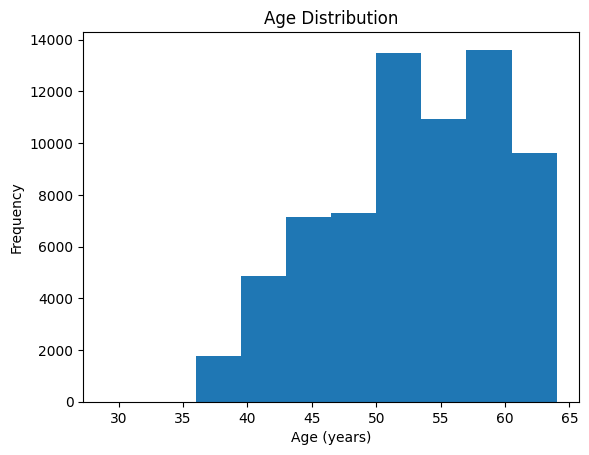

In [ ]:
plt.hist(df['age'])
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


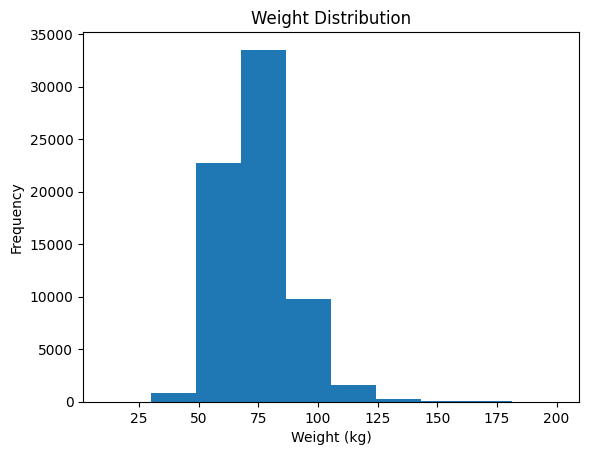

In [ ]:
plt.hist(df['weight'])
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.title("Weight Distribution")
plt.show()


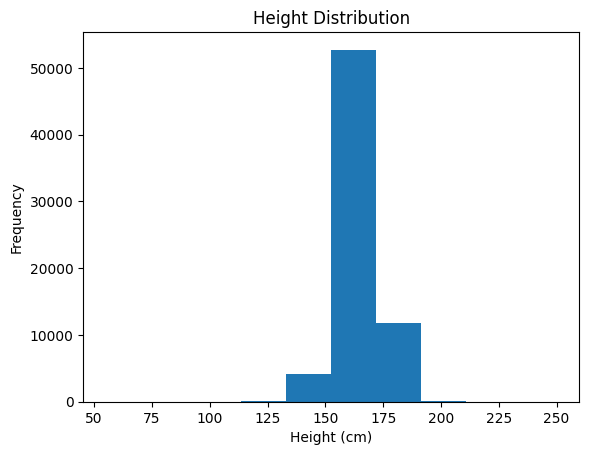

In [ ]:
plt.hist(df['height'])
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.title("Height Distribution")
plt.show()


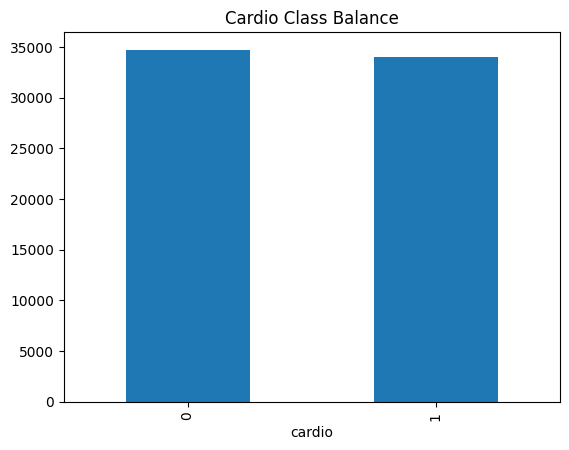

In [ ]:
df['cardio'].value_counts().plot(kind='bar')
plt.title("Cardio Class Balance")
plt.show()


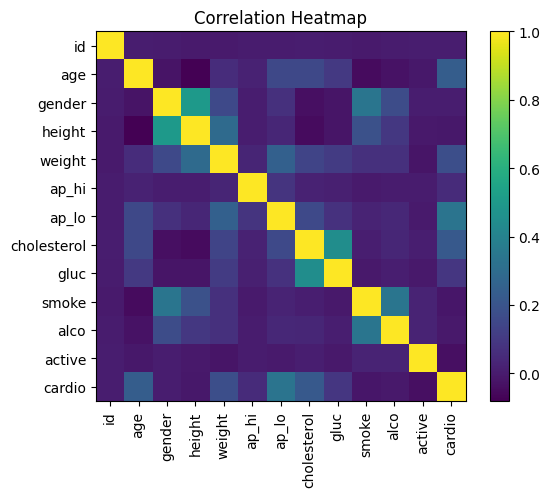

In [ ]:
plt.imshow(df.corr(), cmap='viridis')
plt.colorbar()
plt.xticks(range(len(df.corr().columns)), df.corr().columns, rotation=90)
plt.yticks(range(len(df.corr().columns)), df.corr().columns)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['cardio'], axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.724270856062259
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      7046
           1       0.73      0.68      0.71      6703

    accuracy                           0.72     13749
   macro avg       0.72      0.72      0.72     13749
weighted avg       0.72      0.72      0.72     13749



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.6687031784129754
              precision    recall  f1-score   support

           0       0.67      0.68      0.68      7046
           1       0.66      0.65      0.66      6703

    accuracy                           0.67     13749
   macro avg       0.67      0.67      0.67     13749
weighted avg       0.67      0.67      0.67     13749



In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.7327805658593353
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      7046
           1       0.74      0.69      0.72      6703

    accuracy                           0.73     13749
   macro avg       0.73      0.73      0.73     13749
weighted avg       0.73      0.73      0.73     13749



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.6320459669794167
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      7046
           1       0.62      0.64      0.63      6703

    accuracy                           0.63     13749
   macro avg       0.63      0.63      0.63     13749
weighted avg       0.63      0.63      0.63     13749



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7231071350643683
              precision    recall  f1-score   support

           0       0.72      0.75      0.73      7046
           1       0.72      0.70      0.71      6703

    accuracy                           0.72     13749
   macro avg       0.72      0.72      0.72     13749
weighted avg       0.72      0.72      0.72     13749



In [ ]:
models = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

models


{'Logistic Regression': 0.724270856062259,
 'KNN': 0.6687031784129754,
 'SVM': 0.7327805658593353,
 'Decision Tree': 0.6320459669794167,
 'Random Forest': 0.7231071350643683}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7076878318423158
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      7046
           1       0.71      0.67      0.69      6703

    accuracy                           0.71     13749
   macro avg       0.71      0.71      0.71     13749
weighted avg       0.71      0.71      0.71     13749



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


RF Accuracy: 0.7256527747472543
              precision    recall  f1-score   support

           0       0.72      0.75      0.74      7046
           1       0.73      0.70      0.71      6703

    accuracy                           0.73     13749
   macro avg       0.73      0.73      0.73     13749
weighted avg       0.73      0.73      0.73     13749



In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Logistic Regression Accuracy: 0.7076878318423158
Random Forest Accuracy: 0.7256527747472543


In [ ]:
import joblib
joblib.dump(rf, "best_model.pkl")


['best_model.pkl']

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histogram for all features
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

# 2. Boxplots (to detect outliers)
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# 3. Distribution of target variable
sns.countplot(x='cardio', data=df)
plt.title("Cardio Distribution")
plt.show()

# 4. Gender vs Cardio
sns.countplot(x='gender', hue='cardio', data=df)
plt.title("Gender vs Cardio")
plt.show()

# 5. Cholesterol vs cardio
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

# 6. Scatterplot BMI vs Age
sns.scatterplot(x='age', y='BMI', hue='cardio', data=df)
plt.title("BMI vs Age (Colored by Heart Disease)")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


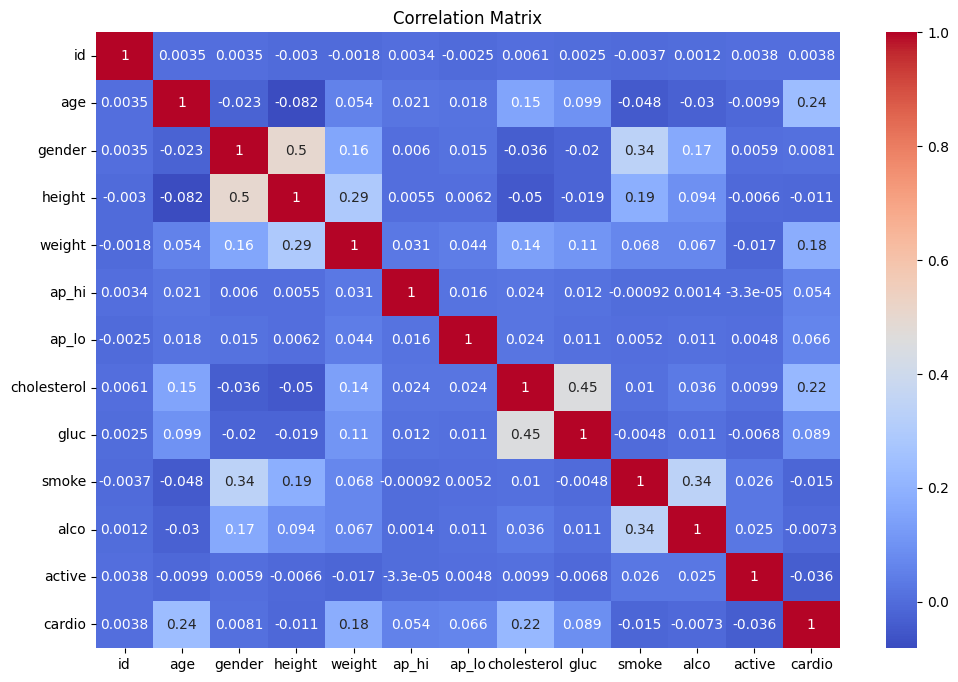

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Separate features and target
X = df.drop('cardio', axis=1)
y = df['cardio']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression:", lr_acc)
print("SVM:", svm_acc)
print("KNN:", knn_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)


Logistic Regression: 0.7233571428571428
SVM: 0.7298571428571429
KNN: 0.6278571428571429
Decision Tree: 0.6338571428571429
Random Forest: 0.7244285714285714


In [ ]:
models = {
    "Logistic Regression": lr_acc,
    "SVM": svm_acc,
    "KNN": knn_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc
}

for name, acc in models.items():
    print(name, ":", acc)

best_model = max(models, key=models.get)
print("\nBest Model =", best_model)


Logistic Regression : 0.7233571428571428
SVM : 0.7298571428571429
KNN : 0.6278571428571429
Decision Tree : 0.6338571428571429
Random Forest : 0.7244285714285714

Best Model = SVM
